In [ ]:
# Deleted this initial section because I got a weird OSError at !pip install CoolProp. 

# Package installation and loading

# Install CoolProp
#!pip install CoolProp

# Import necessary packages
import numpy as np
import matplotlib.pyplot as plt
from CoolProp.CoolProp import PropsSI
# Add more pakcages as needed


In [23]:
# Q1

# I had to re-import these because I kept getting no-name errors.
import numpy as np
import matplotlib.pyplot as plt
import CoolProp.CoolProp as CP

def temperatureConversion(value, unit):
    # Normalize unit
    unit = unit.upper()

    # Convert input to Kelvin
    if unit == 'K':
        T_K = value
    elif unit == 'C':
        T_K = value + 273.15
    elif unit == 'F':
        T_K = (value - 32) * 5/9 + 273.15
    elif unit == 'R':
        T_K = value * 5/9
    else:
        raise ValueError("Unit must be either 'K', 'C', 'F', or 'R'.")

    # Convert to all other scales
    T_C = T_K - 273.15
    T_F = (T_K - 273.15) * 9/5 + 32
    T_R = T_K * 9/5

    # Verifying Kelvin–Celsius relation
    check_H2O = CP.PropsSI("T", "T", T_K, "P", 101325, "Water")

    print(f"{T_K:.2f} K")
    print(f"{T_C:.2f} °C")
    print(f"{T_F:.2f} °F")
    print(f"{T_R:.2f} °R")

# Example test
temperatureConversion(273, 'K')


273.00 K
-0.15 °C
31.73 °F
491.40 °R


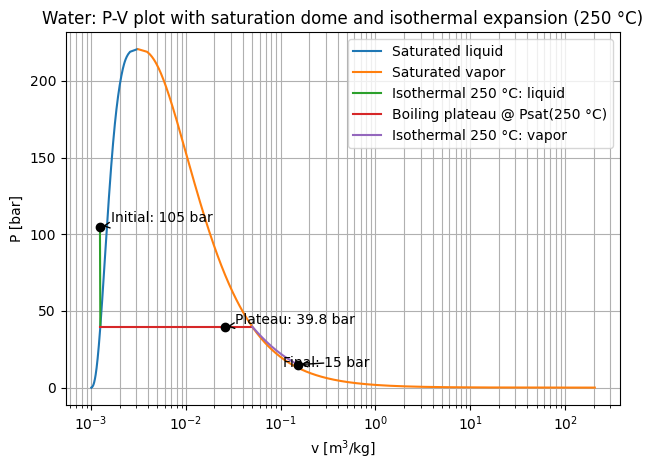

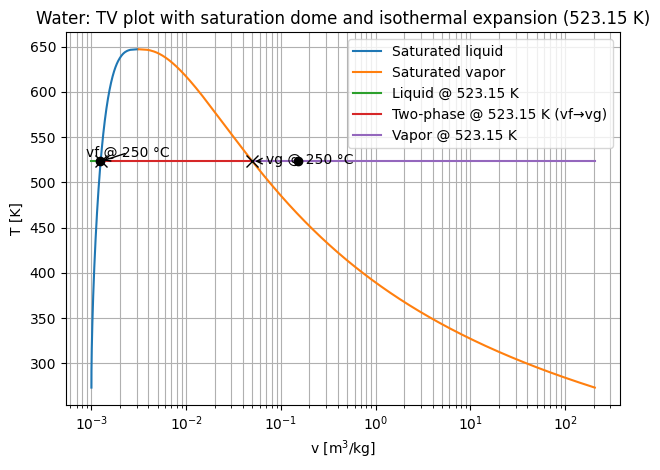

In [24]:
# Q2 

# I had to re-import these because I kept getting no-name errors.
import numpy as np
import matplotlib.pyplot as plt
import CoolProp.CoolProp as CP

# Given
T_iso = 250.0 + 273.15 # K
Pamb_hi, Pamb_lo = 100.0, 10.0 # bar
m_piston, g = 50.0, 9.80 # kg, m/s^2
A_cm2 = 9.8 # cm^2
A = A_cm2 * 1e-4 # m^2

# System pressures (include piston load)
P_load = (m_piston*g/A)/1e5 # = 5 bar
P1, P2 = Pamb_hi + P_load, Pamb_lo + P_load # 105 to 15 bar

# Saturation at 250C
Psat = CP.PropsSI("P","T",T_iso,"Q",0,"Water")/1e5
vf = 1.0/CP.PropsSI("D","T",T_iso,"Q",0,"Water")
vg = 1.0/CP.PropsSI("D","T",T_iso,"Q",1,"Water")

# Safe evaluator in single phase
def v_at(Pbar, eps=1e-3):
    if abs(Pbar - Psat) <= eps*Psat:
        Pbar = Psat*(1+eps) if Pbar > Psat else Psat*(1-eps)
    rho = CP.PropsSI("D","T",T_iso,"P",Pbar*1e5,"Water")
    return 1.0/rho

# Build process: liquid leg to plateau to vapor leg
P_liq = np.linspace(P1, Psat*(1+1e-3), 120)
v_liq = np.array([v_at(p) for p in P_liq])

P_plateau = np.full(160, Psat)
v_plateau = np.linspace(vf, vg, 160)

P_vap = np.linspace(Psat*(1-1e-3), P2, 160)
v_vap = np.array([v_at(p) for p in P_vap])

# End states
v1, v2 = v_at(P1), v_at(P2)

# saturation dome
T_triple = CP.PropsSI("Ttriple","Water") + 1e-3
T_crit   = CP.PropsSI("Tcrit","Water")   - 1e-3
T_vec    = np.linspace(T_triple, T_crit, 600)
P_dome   = CP.PropsSI("P","T",T_vec,"Q",0,"Water")/1e5
vf_dome  = 1.0/CP.PropsSI("D","T",T_vec,"Q",0,"Water")
vg_dome  = 1.0/CP.PropsSI("D","T",T_vec,"Q",1,"Water")

# PLOT 1 (PV)
plt.figure()
plt.semilogx(vf_dome, P_dome, label="Saturated liquid")
plt.semilogx(vg_dome, P_dome, label="Saturated vapor")

plt.semilogx(v_liq, P_liq, label="Isothermal 250 °C: liquid")
plt.semilogx(v_plateau, P_plateau, label="Boiling plateau @ Psat(250 °C)")
plt.semilogx(v_vap, P_vap, label="Isothermal 250 °C: vapor")

# Mark and LABEL defining points
plt.semilogx([v1],[P1],'o',color='k')
plt.annotate("Initial: 105 bar", xy=(v1, P1), xytext=(v1*1.3, P1*1.03),
             arrowprops=dict(arrowstyle="->", lw=1))

mid_v = 0.5*(vf+vg)
plt.semilogx([mid_v],[Psat],'o',color='k')
plt.annotate(f"Plateau: {Psat:.1f} bar", xy=(mid_v, Psat), xytext=(mid_v*1.3, Psat*1.05),
             arrowprops=dict(arrowstyle="->", lw=1))

plt.semilogx([v2],[P2],'o',color='k')
plt.annotate("Final: 15 bar", xy=(v2, P2), xytext=(v2*0.7, P2*0.9),
             arrowprops=dict(arrowstyle="->", lw=1))

plt.xlabel("v [m$^3$/kg]"); plt.ylabel("P [bar]")
plt.title("Water: P-V plot with saturation dome and isothermal expansion (250 °C)")
plt.grid(True, which='both'); plt.legend(); plt.tight_layout(); plt.show()

# PLOT 2 (TV)
plt.figure()
plt.semilogx(vf_dome, T_vec, label="Saturated liquid")
plt.semilogx(vg_dome, T_vec, label="Saturated vapor")

# Isotherm at 523.15 K:
vmin = min(vf_dome.min(), v1*0.8); vmax = max(vg_dome.max(), v2*1.2)
plt.semilogx([vmin, vf], [T_iso, T_iso], label="Liquid @ 523.15 K")
plt.semilogx([vf, vg],   [T_iso, T_iso], label="Two-phase @ 523.15 K (vf→vg)")
plt.semilogx([vg, vmax], [T_iso, T_iso], label="Vapor @ 523.15 K")

# label vf and vg
plt.semilogx([vf],[T_iso],'x',ms=8,color='k')
plt.semilogx([vg],[T_iso],'x',ms=8,color='k')
plt.annotate("vf @ 250 °C", xy=(vf, T_iso), xytext=(vf*0.7, T_iso*1.01),
             arrowprops=dict(arrowstyle="->", lw=1))
plt.annotate("vg @ 250 °C", xy=(vg, T_iso), xytext=(vg*1.4, T_iso*0.995),
             arrowprops=dict(arrowstyle="->", lw=1))

# End-state markers
plt.semilogx([v1],[T_iso],'o',color='k')
plt.semilogx([v2],[T_iso],'o',color='k')

# Final plot construction
plt.xlabel("v [m$^3$/kg]"); plt.ylabel("T [K]")
plt.title("Water: TV plot with saturation dome and isothermal expansion (523.15 K)")
plt.grid(True, which='both'); plt.legend(); plt.tight_layout(); plt.show()
